In [1]:
import tess_asteroids as ta
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import lkprf

# Notes:

* You are currently using a linear interpolation for the asteroid position which isn't doing a good job at turning points, you should use a cubic interpolation.
* You are not saving the row/column position of the asteroid as a property of your class, it seems useful to store

In [2]:
# Initialise MovingTPF for asteroid 1980 VR1 in TESS sector 1
self = ta.MovingTPF.from_name("1980 VR1", sector=1, camera=1, ccd=1)

In [3]:
self

In [4]:
prf = lkprf.TESSPRF(camera=self.camera, ccd=self.ccd, sector=self.sector)

In [5]:
self.get_data()

In [6]:
def get_prf_models(self, nlag=2, ndt=10):
    """
    Get a set of `nlag` prf models for the data

    Parameters:
    -----------
    nlag: int
        number of leading and lagging apertures to create. If nlag is 2, will create two leading and two lagging apertures, as well as the target aperture. 
    ndt: int
        number of sub time points to calculate the prf at. If ndt is 10, will calculate the prf at 10 sub times within each cadence. Set to higher value to capture motion through the TPF.
    
    """
    # velocity in pixels per day
    vel = interp1d(self.ephem["time"].values, 
            np.hypot(np.gradient(self.ephem["row"].values, self.ephem["time"].values),
                     np.gradient(self.ephem["column"].values, self.ephem["time"].values)), kind='cubic', bounds_error=False)(self.time)
    width = 20 # minimum separation in pixels
    # minimum acceptable lag time in units of time
    lag = np.abs(width/np.max(vel))
    lagtime = (np.arange(-nlag, nlag + 1) * lag)
    ndt = 10
    t = self.time[:, None, None] + (np.gradient(self.time)[:, None, None] * np.linspace(-0.5, 0.5, ndt)[None, :, None]) + lagtime[None, None, :]
    
    column_position = interp1d(self.ephem["time"].astype(float),
                             self.ephem["column"].astype(float), kind='cubic', bounds_error=False)(t)
    
    
    row_position = interp1d(self.ephem["time"].astype(float),
                             self.ephem["row"].astype(float), kind='cubic', bounds_error=False)(t)

    origin = tuple(self.pixels.min(axis=0).astype(int))
    shape = tuple((self.pixels.max(axis=0) - self.pixels.min(axis=0) + 1).astype(int))
    R, C = np.mgrid[:shape[0], :shape[1]] + np.asarray(origin)[:, None, None]
    prf_models = np.zeros((nlag * 2 + 1, *self.all_flux.shape))

    # Calculate each time, summing over the subtimes
    for tdx in range(len(self.time)):
        positions = [(r if np.isfinite(r) else -100, c if np.isfinite(c) else -100)
                     for r, c in zip(row_position[tdx].ravel(), column_position[tdx].ravel())]
        prf_model = prf.evaluate(positions,
                     origin=origin,
                     shape=shape).reshape((ndt, nlag * 2 + 1, *shape)).sum(axis=0)
        prf_models[:, tdx, :] = prf_model[:, self.pixels[:, 0] - np.asarray(origin[0]), self.pixels[:, 1] - np.asarray(origin[1])]

    return lagtime, prf_models

In [7]:
lagtime, prf_models = get_prf_models(self, nlag=2, ndt=10)

/Users/chedges/Library/Caches/pypoetry/virtualenvs/tess-asteroids-NxG5Au0G-py3.9/lib/python3.9/site-packages/lkprf/tessprf.py:49: LKPRFWarning: `targets` contains collateral pixels: Column(s) < 45
  warnings.warn(
/Users/chedges/Library/Caches/pypoetry/virtualenvs/tess-asteroids-NxG5Au0G-py3.9/lib/python3.9/site-packages/lkprf/tessprf.py:56: LKPRFWarning: `targets` contains collateral pixels: Column(s) >= 2093 
  warnings.warn(


In [8]:
prf_models.shape

(5, 905, 7935)

Below is an example of the PRF models this function creates. Each PRF model is valued between 0 and 1 for every pixel for every time. There are "leading" and "lagging" PRF models which are the PRF for a theoretical object leading or lagging the true object by a cetain time offset. 

/var/folders/bv/0t7fjlgx0mx3_3bdhxqzd7bmh_67k0/T/ipykernel_25529/3035203845.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(-100, -100, c=cmap(0.5), label=f'Lagtime {np.round(lagtime[idx], 1)}')


/Users/chedges/Library/Caches/pypoetry/virtualenvs/tess-asteroids-NxG5Au0G-py3.9/lib/python3.9/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


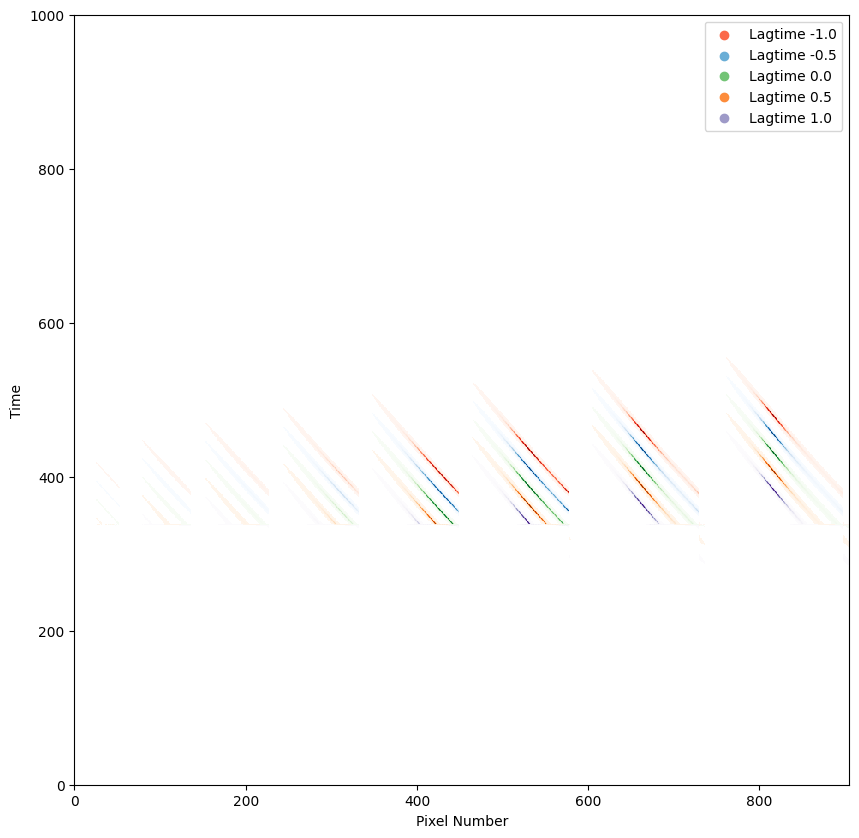

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))
for idx, color in enumerate(['Reds', 'Blues', 'Greens', 'Oranges', 'Purples']):
    cmap = plt.get_cmap(color)
    cmap.set_bad(alpha=0)
    a = (prf_models[idx][:, :1000]).astype(float)
    a[a == 0] = np.nan
    ax.pcolormesh(a, cmap=cmap)
    ax.scatter(-100, -100, c=cmap(0.5), label=f'Lagtime {np.round(lagtime[idx], 1)}')
ax.set(ylabel='Time', xlabel='Pixel Number', xlim=(0, len(self.time)), ylim=(0, 1000))
ax.legend()

In [10]:
from fbpca import pca
from tqdm import tqdm
ncomponents = 5
box_width = 50
sigmas = 6
polyorder = 2

spoc_quality_mask = self.quality & (1|2|4|8|32|512) == 0

aper = prf_models[lagtime == 0][0] != 0
bkg_model = np.zeros(self.all_flux.shape)
dt = np.median(np.diff(self.time))

t = (self.time - self.time.mean())
t /= (self.time[-1] - self.time[0])

for tdx in tqdm(np.arange(self.all_flux.shape[0])):
    adx, bdx = np.max([tdx - box_width//2, 0]), np.min([tdx + box_width//2, self.all_flux.shape[0]])
    tmin, tmax = self.time[tdx] - (dt * box_width), self.time[tdx] + (dt * box_width)

    # build the PCA components from all pixels using the box width time range, ignoring pixels that contain the asteroid
    U, s, V = pca(self.all_flux[adx:bdx, ~aper[adx:bdx].any(axis=0)], k=ncomponents, raw=True, n_iter=5)
    
    # fit the components to the data, masking out the asteroid, and iteratively sigma clipping
    # here we assume that there is enough data in the pixel timeseries to fit the model.
    
    # We are fitting a model which is the pca components and a polynomial trend in time.
    X = np.hstack([np.vstack([(t[adx:bdx] - t[adx:bdx].mean())**idx for idx in range(polyorder + 1)]).T, U])
    w, werr = np.zeros((2, self.all_flux.shape[1], X.shape[1]))
    prior_mu = np.zeros(X.shape[1])
    prior_sigma = np.ones(X.shape[1]) * 1e4
    
    # iterate over all relevant pixels where there is either a target aperture or a leading/lagging aperture
    relevant_pixels = np.where((prf_models[:, adx:bdx] > 0).any(axis=(0, 1)))[0]
    for pdx in relevant_pixels:
        # cut out any values where the asteroid is present
        k = ~aper[adx:bdx][:, pdx]
        # cut out cadences with bad quality according to SPOC
        k &= spoc_quality_mask[adx:bdx]
        # cut out cadences that are more than 1 box width away on either side.
        # This tolerates small gaps, but will cut out cadences that are over a big discontinuity (e.g. data downlink).
        k &= (self.time[adx:bdx] > tmin) & (self.time[adx:bdx] < tmax)
        
        # prior is that the first component should be close to the median of the pixel flux value
        prior_mu[0] = np.nanmedian(self.all_flux[adx:bdx][k, pdx])
        prior_sigma[0] = prior_mu[0]**0.5

        # iterate over each sigma clip value
        for sigma in np.atleast_1d(sigmas):
            # fit the timeseries
            if not k.any():
                # if there are no pixels with which to fit, return nan.
                w[pdx] = np.nan
                continue
            else:
                sigma_w_inv = X[k].T.dot(X[k]/self.all_flux_err[adx:bdx][k, pdx, None]**2) + np.diag(1/prior_sigma**2)
                B = X[k].T.dot(self.all_flux[adx:bdx][k, pdx]/self.all_flux_err[adx:bdx][k, pdx]**2) + prior_mu/prior_sigma**2
                w[pdx] = np.linalg.solve(sigma_w_inv, B)
                # add to the mask any pixels that are significant outliers
                k &= np.abs(self.all_flux[adx:bdx][:, pdx] - X.dot(w[pdx]))/(self.all_flux_err[adx:bdx][:, pdx]) < sigma
    bkg_model[tdx] = X[np.arange(adx, bdx) == tdx].dot(w.T)[0]

100%|█████████████████████████████████████████| 905/905 [02:25<00:00,  6.21it/s]


In [11]:
# This is the index of the PRF model that has the true object in it
ast_aper_mask = lagtime != 0

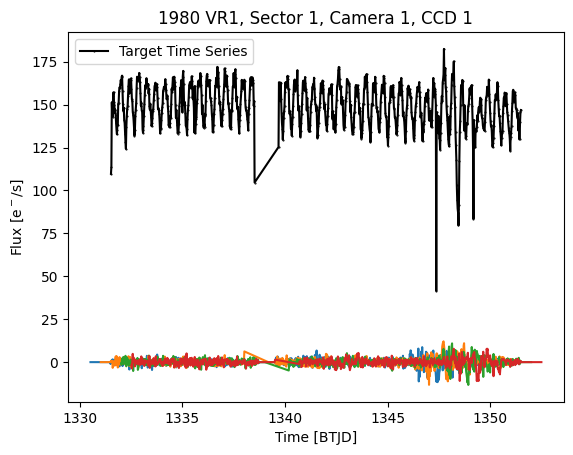

In [12]:
flux_limit = 0.1
k = spoc_quality_mask

fig, ax = plt.subplots()
ax.plot((self.time[k][None, :] + lagtime[ast_aper_mask, None]).T, ((self.all_flux[k][None, :, :] - bkg_model[k]) * (prf_models[:, k][ast_aper_mask] > flux_limit)).sum(axis=(2)).T);
ax.plot(self.time[k], ((self.all_flux[k] - bkg_model[k]) * (prf_models[lagtime == 0][0][k] > flux_limit)).sum(axis=(1)), c='k', marker='.', markersize=1, label='Target Time Series');
ax.set(xlabel='Time [BTJD]', ylabel='Flux [e$^-$/s]', title=f"{self.target}, Sector {self.sector}, Camera {self.camera}, CCD {self.ccd}")
ax.legend()